<a href="https://colab.research.google.com/github/ashok-bisht/Context-Aware_Misinformation_Detection_ML_and_Gen_AI/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimized XGBoost pipeline using the already-cleaned columns:
title, content, subject, label, cleaned_title, cleaned_content, cleaned_subject

Key optimizations vs. before:
- TF-IDF built in-memory as a SPARSE matrix, never written to CSV (avoids the 5GB file problem)
- Sparse hstack for combining text + subject features (no densifying anywhere)
- float32 instead of float64 for numeric features (halves memory)
- Saves final matrix as .npz (fast to reload later, tiny on disk) instead of CSV


In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix, save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import pickle


In [74]:
CSV_PATH = "/content/drive/MyDrive/ML-CDAC-PROJECT/cleaned_news_data.csv"
RANDOM_STATE = 42
K_BEST_FEATURES = 10_000

 Load

In [ ]:
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["cleaned_title", "cleaned_content", "label"]).reset_index(drop=True)
df["cleaned_subject"] = df["cleaned_subject"].fillna("unknown")

Remove duplicates FIRST, before any split

In [ ]:
df = df.drop_duplicates(subset=["cleaned_content"]).reset_index(drop=True)
print("After dedup:", df.shape)

After dedup: (38557, 8)


Combine cleaned title + content (title repeated once — usually denser signal than body)

In [ ]:
df["text"] = (
    df["cleaned_title"].astype(str) + " " +
    df["cleaned_title"].astype(str) + " " +
    df["cleaned_content"].astype(str)
)
y = df["label"].astype(int).values

In [ ]:
df["text"] = df["cleaned_title"] + " " + df["cleaned_title"] + " " + df["cleaned_content"]
y = df["label"].astype(int).values

TF-IDF (sparse, in-memory only — never save this as CSV)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    # no need for stop_words="english" here — your cleaning step likely already removed them
)

In [ ]:
X_text = tfidf.fit_transform(df["text"])   # sparse matrix, a few hundred MB not GBs
print("TF-IDF shape:", X_text.shape, "| nonzero:", X_text.nnz)

TF-IDF shape: (38557, 50000) | nonzero: 7232520


Subject one-hot (sparse)

In [ ]:
#ohe = OneHotEncoder(handle_unknown="ignore")
#X_subj = ohe.fit_transform(df[["cleaned_subject"]])

Cheap numeric features

In [ ]:
title_len = df["cleaned_title"].str.len().values.astype(np.float32)
content_len = df["cleaned_content"].str.len().values.astype(np.float32)
word_count = df["cleaned_content"].str.split().str.len().values.astype(np.float32)
X_num = csr_matrix(np.column_stack([title_len, content_len, word_count]))

Combine everything (still sparse)

In [ ]:
X = hstack([X_text, X_num]).tocsr()
print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (38557, 50003)


In [63]:
import pickle

with open("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/tfidf_sparse.pkl", "wb") as f:
    pickle.dump(X, f)

with open("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/labels.pkl", "wb") as f:
    pickle.dump(y, f)

with open("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/encoders.pkl", "wb") as f:
    pickle.dump((tfidf, ohe), f)

print("Saved sparse features -> tfidf_sparse.pkl (reload with pickle.load)")

Saved sparse features -> tfidf_sparse.pkl (reload with pickle.load)


Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)

Train XGBoost

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",              # <-- add this line, this is what actually engages the T4
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

[0]	validation_0-logloss:0.64032
[50]	validation_0-logloss:0.05090
[100]	validation_0-logloss:0.01666
[150]	validation_0-logloss:0.01286
[200]	validation_0-logloss:0.01172
[250]	validation_0-logloss:0.01150
[300]	validation_0-logloss:0.01149
[312]	validation_0-logloss:0.01148


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device='cuda', early_stopping_rounds=30,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

Evaluate

In [ ]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost test set results ===")
print(classification_report(y_test, preds, digits=4))
print("ROC AUC:", roc_auc_score(y_test, probs))


=== XGBoost test set results ===
              precision    recall  f1-score   support

           0     0.9974    0.9965    0.9970      3478
           1     0.9972    0.9979    0.9975      4234

    accuracy                         0.9973      7712
   macro avg     0.9973    0.9972    0.9973      7712
weighted avg     0.9973    0.9973    0.9973      7712

ROC AUC: 0.9997743084746472


In [ ]:
#print(df.groupby("cleaned_subject")["label"].value_counts())

cleaned_subject  label
government news  0          895
left news        0         2401
middle east      0          401
news             0         9050
politics         0         4262
politicsnews     1        11196
unknown          0          382
worldnews        1         9970
Name: count, dtype: int64


Save model

In [64]:

import pickle

with open("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("\nSaved model -> xgb_model.pkl")


Saved model -> xgb_model.pkl


In [ ]:
#print(df.duplicated(subset=["cleaned_content"]).sum())

0


In [ ]:
with open("tfidf_sparse.pkl", "rb") as f:
    X = pickle.load(f)

with open("labels.pkl", "rb") as f:
    y = pickle.load(f)

print("Loaded X:", X.shape, "| y:", y.shape)

Loaded X: (38557, 50003) | y: (38557,)


Naive Bayes

In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_preds = nb.predict(X_test)
nb_probs = nb.predict_proba(X_test)[:, 1]

print("\n=== Naive Bayes test set results ===")
print(classification_report(y_test, nb_preds, digits=4))
print("ROC AUC:", roc_auc_score(y_test, nb_probs))



=== Naive Bayes test set results ===
              precision    recall  f1-score   support

           0     0.6944    0.8364    0.7588      3478
           1     0.8385    0.6977    0.7616      4234

    accuracy                         0.7602      7712
   macro avg     0.7665    0.7670    0.7602      7712
weighted avg     0.7735    0.7602    0.7604      7712

ROC AUC: 0.8600806934634411


# NB - COMPLEMENTNB

In [68]:
from sklearn.naive_bayes import ComplementNB

nb = ComplementNB()
nb.fit(X_train, y_train)

ComplementNB()

In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import ComplementNB

param_grid = {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0]}
grid = GridSearchCV(ComplementNB(), param_grid, cv=3, scoring="f1")
grid.fit(X_train, y_train)
print(grid.best_params_)

nb = grid.best_estimator_

{'alpha': 0.01}


In [70]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(max_features=50_000, ngram_range=(1, 2))
X_counts = count_vec.fit_transform(df["text"])   # rebuild specifically for NB, separate from your TF-IDF X

# then split X_counts the same way, train NB on that instead

In [75]:
selector = SelectKBest(chi2, k=K_BEST_FEATURES)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)
print("Selected feature matrix shape:", X_train_sel.shape)

Selected feature matrix shape: (26218, 10000)


In [76]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=10_000)   # keep only the most informative 10k features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

nb.fit(X_train_selected, y_train)

ComplementNB(alpha=0.01)

In [77]:
preds = nb.predict(X_test_sel)
probs = nb.predict_proba(X_test_sel)[:, 1]

print("\n=== Improved Naive Bayes (ComplementNB) test set results ===")
print(classification_report(y_test, preds, digits=4))
print("ROC AUC:", roc_auc_score(y_test, probs))



=== Improved Naive Bayes (ComplementNB) test set results ===
              precision    recall  f1-score   support

           0     0.7330    0.8571    0.7902      3478
           1     0.8636    0.7435    0.7991      4234

    accuracy                         0.7947      7712
   macro avg     0.7983    0.8003    0.7946      7712
weighted avg     0.8047    0.7947    0.7951      7712

ROC AUC: 0.8901056455001721


Linear SVM

In [ ]:
from sklearn.preprocessing import MaxAbsScaler   # works with sparse matrices, unlike StandardScaler
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm_base = LinearSVC(random_state=RANDOM_STATE, max_iter=20000)
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_train, y_train)

svm_preds = svm.predict(X_test)
svm_probs = svm.predict_proba(X_test)[:, 1]

print("\n=== Linear SVM test set results ===")
print(classification_report(y_test, svm_preds, digits=4))
print("ROC AUC:", roc_auc_score(y_test, svm_probs))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== Linear SVM test set results ===
              precision    recall  f1-score   support

           0     0.9485    0.9209    0.9345      3478
           1     0.9366    0.9589    0.9476      4234

    accuracy                         0.9418      7712
   macro avg     0.9425    0.9399    0.9411      7712
weighted avg     0.9419    0.9418    0.9417      7712

ROC AUC: 0.9839603847709455


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [65]:
with open("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/nb_model.pkl", "wb") as f:
    pickle.dump(nb, f)

with open("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/svm_model.pkl", "wb") as f:
    pickle.dump(svm, f)

print("\nSaved -> nb_model.pkl, svm_model.pkl")


Saved -> nb_model.pkl, svm_model.pkl


 Logistic Regression

In [ ]:
lr = LogisticRegression(
    max_iter=1000,          # TF-IDF + high dimensionality often needs more iterations to converge
    solver="liblinear",     # handles sparse matrices well, good default for high-dim sparse text
    random_state=RANDOM_STATE,
)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression test set results ===")
print(classification_report(y_test, lr_preds, digits=4))
print("ROC AUC:", roc_auc_score(y_test, lr_probs))


=== Logistic Regression test set results ===
              precision    recall  f1-score   support

           0     0.9877    0.9675    0.9775      3478
           1     0.9738    0.9901    0.9818      4234

    accuracy                         0.9799      7712
   macro avg     0.9807    0.9788    0.9797      7712
weighted avg     0.9800    0.9799    0.9799      7712

ROC AUC: 0.9980276862758094


Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,         # let trees grow fully; sparse TF-IDF usually benefits from this
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest test set results ===")
print(classification_report(y_test, rf_preds, digits=4))
print("ROC AUC:", roc_auc_score(y_test, rf_probs))



=== Random Forest test set results ===
              precision    recall  f1-score   support

           0     0.9968    0.9922    0.9945      3478
           1     0.9936    0.9974    0.9955      4234

    accuracy                         0.9951      7712
   macro avg     0.9952    0.9948    0.9950      7712
weighted avg     0.9951    0.9951    0.9951      7712

ROC AUC: 0.9997950543031399


In [66]:
with open("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/lr_model.pkl", "wb") as f:
    pickle.dump(lr, f)

with open("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("\nSaved -> lr_model.pkl, rf_model.pkl")


Saved -> lr_model.pkl, rf_model.pkl


Load all trained models

In [ ]:
model_files = {
    "Naive Bayes": "nb_model.pkl",
    "Linear SVM": "svm_model.pkl",
    "Logistic Regression": "lr_model.pkl",
    "Random Forest": "rf_model.pkl",
    "XGBoost": "xgb_model.pkl",
}

models = {}
for name, path in model_files.items():
    try:
        with open(path, "rb") as f:
            models[name] = pickle.load(f)
    except FileNotFoundError:
        print(f"Warning: {path} not found — skipping {name}")

Evaluate each -

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
results = []
for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, probs),
    })

    comparison_df = pd.DataFrame(results).set_index("Model").round(4)

print("=" * 70)
print("MODEL COMPARISON — leak-free test set")
print("=" * 70)
print(comparison_df.to_string())



MODEL COMPARISON — leak-free test set
                     Accuracy  Precision  Recall      F1  ROC AUC
Model                                                            
Naive Bayes            0.7602     0.8385  0.6977  0.7616   0.8601
Linear SVM             0.9418     0.9366  0.9589  0.9476   0.9840
Logistic Regression    0.9799     0.9738  0.9901  0.9818   0.9980
Random Forest          0.9951     0.9936  0.9974  0.9955   0.9998
XGBoost                0.9973     0.9972  0.9979  0.9975   0.9998


Bar chart

Saved -> model_comparison.png


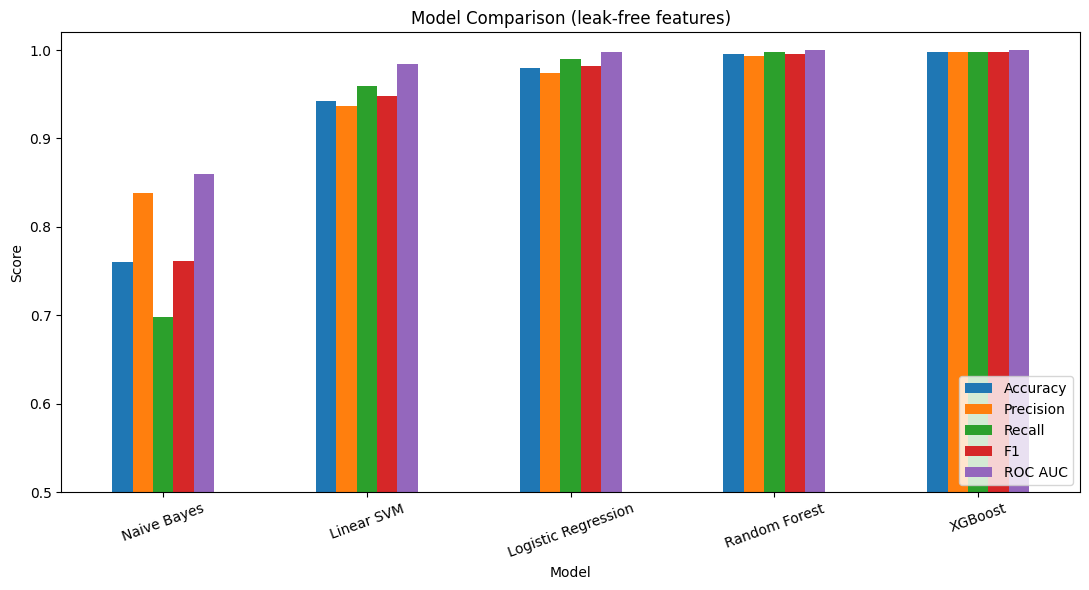

In [67]:
import matplotlib.pyplot as plt

ax = comparison_df.plot(kind="bar", figsize=(11, 6), rot=20)
ax.set_ylim(0.5, 1.02)   # zoom in — differences at the top matter most here
ax.set_ylabel("Score")
ax.set_title("Model Comparison (leak-free features)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML-CDAC-PROJECT/Pickle-files/model_comparison.png", dpi=150)
print("Saved -> model_comparison.png")
plt.show()